In [1]:
import os
import duckdb
import pandas as pd
from IPython.display import Image

# ETL Pipeline for the Olist E-Commerce dataset.
**Objective**: Create a single analytical table with all the information needed to run our experiment.

### 1. Load dataset into a duckdb database.

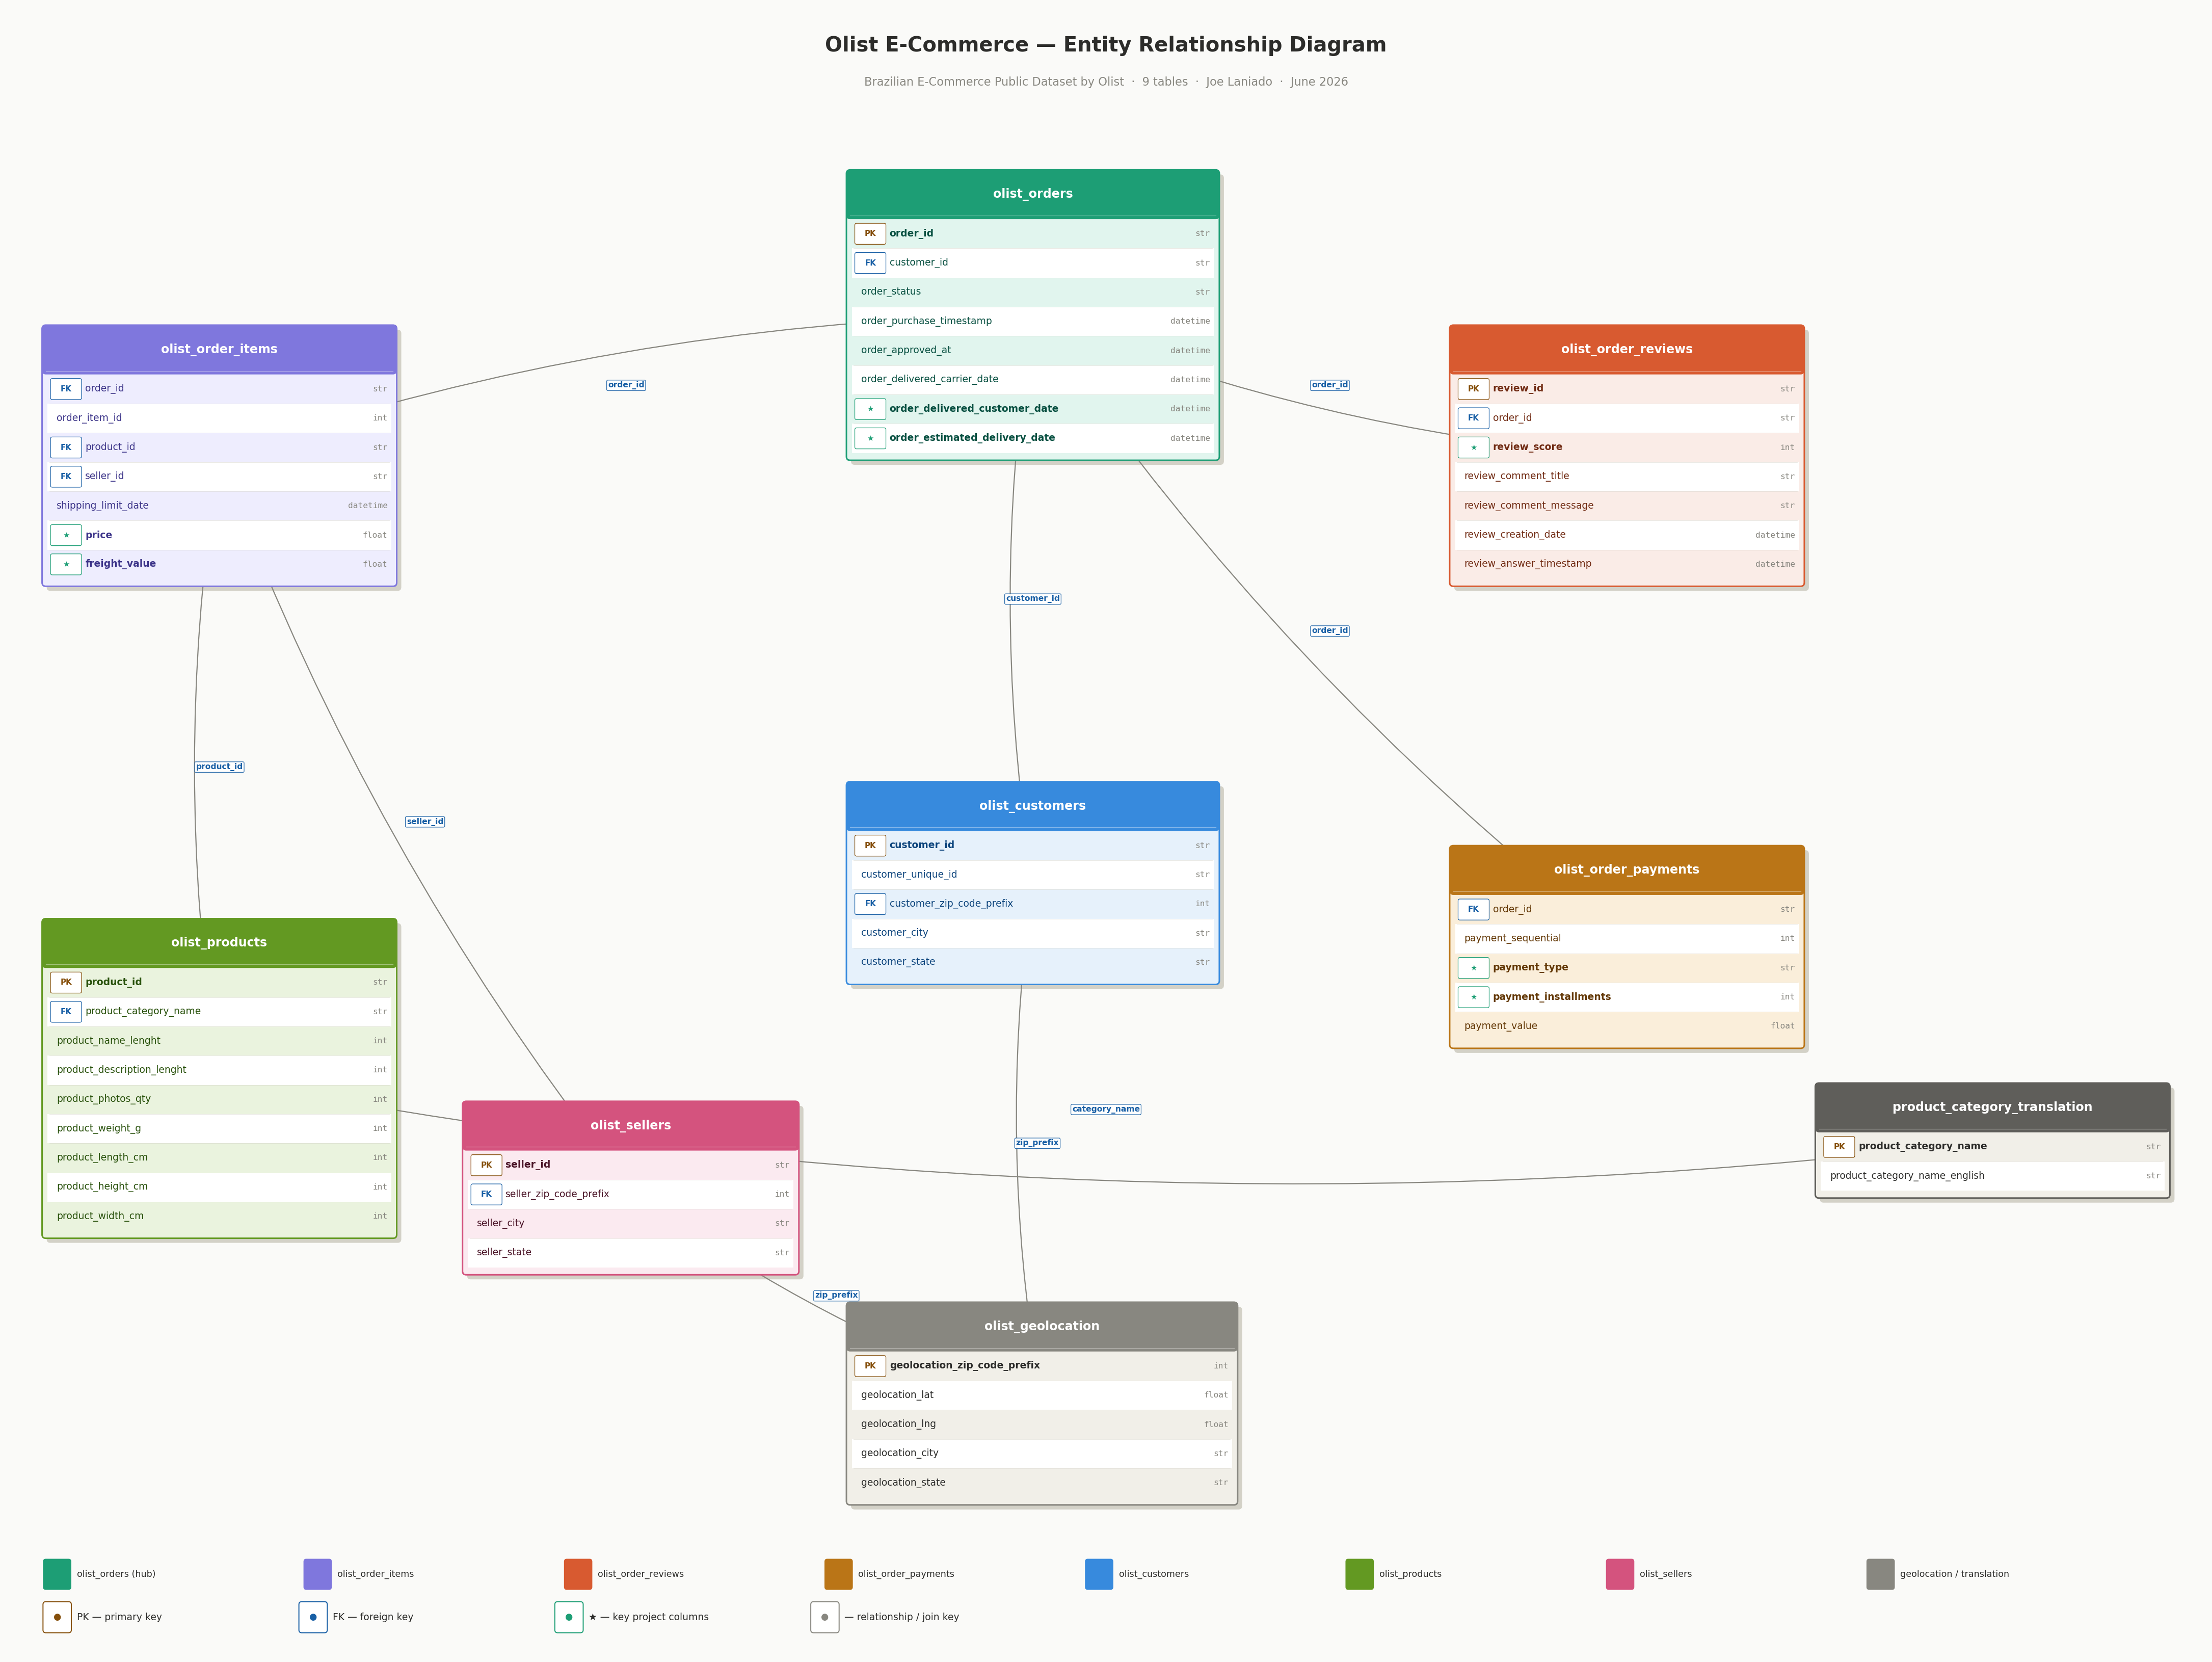

In [2]:
Image("olist_erd.png")

In [3]:
# Declare in memory db
con = duckdb.connect()

files = {
    'orders':      'olist_orders_dataset.csv',
    'reviews':     'olist_order_reviews_dataset.csv',
    'items':       'olist_order_items_dataset.csv',
    'payments':    'olist_order_payments_dataset.csv',
    'customers':   'olist_customers_dataset.csv',
    'products':    'olist_products_dataset.csv',
    'sellers':     'olist_sellers_dataset.csv',
    'translation': 'product_category_name_translation.csv'}

for name, path in files.items():
    con.execute(f"CREATE VIEW {name} as SELECT * FROM read_csv_auto('raw_data/{path}')")

total_rows = con.execute('SELECT COUNT(order_id) FROM orders').fetchone()[0]

print(f"There is a total of {total_rows} distinct orders in our dataset")

row_count = [total_rows]

There is a total of 99441 distinct orders in our dataset


## Transformations ------------------------------------------------------------------------------------------------

In [4]:
# 1. Get orders that are completed, account for the first eligible purchase of a customer, and limit to 
# a 12 month period to maintain one independent observation per customer.
df1 = con.execute(''' SELECT o.order_id,
                            c.customer_unique_id,
                            c.customer_state,
                            o.order_purchase_timestamp
                  FROM orders o
                  JOIN customers c ON o.customer_id = c.customer_id
                  WHERE order_status = 'delivered'
                  AND o.order_purchase_timestamp >= '2017-08-01'
                  AND o.order_purchase_timestamp < '2018-08-01'
                  QUALIFY ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id
                                            ORDER BY o.order_purchase_timestamp ASC, o.order_id ASC) = 1
                  ''').df()

print(df1.info(),
      f"\nTotal unique orders: {df1['order_id'].nunique()}")

row_count.append(df1['order_id'].nunique())


<class 'pandas.DataFrame'>
RangeIndex: 70054 entries, 0 to 70053
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  70054 non-null  str           
 1   customer_unique_id        70054 non-null  str           
 2   customer_state            70054 non-null  str           
 3   order_purchase_timestamp  70054 non-null  datetime64[us]
dtypes: datetime64[us](1), str(3)
memory usage: 2.1 MB
None 
Total unique orders: 70054


In [5]:
# 2. Add customer reviews for each order accounting for orders with multiple reviews.
df2 = con.execute(''' 
                    WITH first_review AS (
                            SELECT order_id, FIRST(review_score ORDER BY review_creation_date ASC, review_id ASC) as customer_rating
                            FROM reviews
                            GROUP BY order_id )
                            
                    SELECT df1.*,
                            r.customer_rating
                    FROM df1 INNER JOIN first_review as r 
                    on df1.order_id = r.order_id 
                    ''').df()
print(df2.info(),
      f"\nTotal unique orders: {df2['order_id'].nunique()}")

row_count.append(df2['order_id'].nunique())


<class 'pandas.DataFrame'>
RangeIndex: 69589 entries, 0 to 69588
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  69589 non-null  str           
 1   customer_unique_id        69589 non-null  str           
 2   customer_state            69589 non-null  str           
 3   order_purchase_timestamp  69589 non-null  datetime64[us]
 4   customer_rating           69589 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 2.7 MB
None 
Total unique orders: 69589


In [6]:
# 3. Calculate orders with only one item and filter.
df3 = con.execute('''
            WITH single_orders AS (
                    SELECT order_id, COUNT(order_item_id) as n_items
                    FROM items
                    GROUP BY order_id
                    HAVING n_items = 1 )
            
            SELECT df2.*
            FROM df2 INNER JOIN single_orders on df2.order_id = single_orders.order_id ''').df()
print(df3.info(),
      f"\nTotal unique orders: {df3['order_id'].nunique()}")

row_count.append(df3['order_id'].nunique())


<class 'pandas.DataFrame'>
RangeIndex: 62658 entries, 0 to 62657
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  62658 non-null  str           
 1   customer_unique_id        62658 non-null  str           
 2   customer_state            62658 non-null  str           
 3   order_purchase_timestamp  62658 non-null  datetime64[us]
 4   customer_rating           62658 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 2.4 MB
None 
Total unique orders: 62658


In [7]:
# 4. Get information about price, product, and seller.
df4 = con.execute('''
                SELECT df3.*,
                        i.product_id,
                        i.seller_id,
                        i.price,
                        i.freight_value,
                        COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS product_category
                FROM df3 
                LEFT JOIN items i ON df3.order_id = i.order_id AND i.order_item_id = 1
                LEFT JOIN products p ON i.product_id = p.product_id
                LEFT JOIN translation t ON p.product_category_name = t.product_category_name''').df()
print(df4.info(),
      f"\nTotal unique orders: {df4['order_id'].nunique()}")

row_count.append(df4['order_id'].nunique())


<class 'pandas.DataFrame'>
RangeIndex: 62658 entries, 0 to 62657
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  62658 non-null  str           
 1   customer_unique_id        62658 non-null  str           
 2   customer_state            62658 non-null  str           
 3   order_purchase_timestamp  62658 non-null  datetime64[us]
 4   customer_rating           62658 non-null  int64         
 5   product_id                62658 non-null  str           
 6   seller_id                 62658 non-null  str           
 7   price                     62658 non-null  float64       
 8   freight_value             62658 non-null  float64       
 9   product_category          62658 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(6)
memory usage: 4.8 MB
None 
Total unique orders: 62658


In [8]:
# Add Dates to each Order, Product, Seller.
order_dates = con.execute("""
        SELECT DISTINCT
            i.order_id,
            i.product_id,
            i.seller_id,
            i.price,
            o.order_purchase_timestamp
        FROM orders o INNER JOIN items i 
        ON o.order_id = i.order_id""").df()

# Calculate Max historical price and number of observations for each product-seller pair before each purchase date.
df5 = con.execute("""
    WITH price_history AS (
        SELECT
            current.order_id,
            current.product_id,
            current.seller_id,
            current.price,
            current.order_purchase_timestamp,
            MAX(history.price) AS prior_max_price,
            COUNT(history.order_id) AS n_prior_price_obs
        FROM order_dates current LEFT JOIN order_dates history
        ON current.seller_id = history.seller_id AND current.product_id = history.product_id 
        AND history.order_purchase_timestamp < current.order_purchase_timestamp
        GROUP BY ALL)

    SELECT
        df4.*,
        ph.prior_max_price,
        ph.n_prior_price_obs,
        GREATEST(0, ((ph.prior_max_price - df4.price)/ ph.prior_max_price) * 100) AS discount_ptg
    FROM df4 JOIN price_history ph ON df4.order_id = ph.order_id
    AND df4.product_id = ph.product_id AND df4.seller_id = ph.seller_id
    WHERE ph.n_prior_price_obs >= 3
    """).df()

print(df5.info(),
      f"\nTotal unique orders: {df5['order_id'].nunique()}")

row_count.append(df5['order_id'].nunique())

<class 'pandas.DataFrame'>
RangeIndex: 31004 entries, 0 to 31003
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  31004 non-null  str           
 1   customer_unique_id        31004 non-null  str           
 2   customer_state            31004 non-null  str           
 3   order_purchase_timestamp  31004 non-null  datetime64[us]
 4   customer_rating           31004 non-null  int64         
 5   product_id                31004 non-null  str           
 6   seller_id                 31004 non-null  str           
 7   price                     31004 non-null  float64       
 8   freight_value             31004 non-null  float64       
 9   product_category          31004 non-null  str           
 10  prior_max_price           31004 non-null  float64       
 11  n_prior_price_obs         31004 non-null  int64         
 12  discount_ptg              310

In [9]:
df5.describe()

,order_purchase_timestamp,customer_rating,price,freight_value,prior_max_price,n_prior_price_obs,discount_ptg
count,31004,31004.000000,31004.000000,31004.000000,31004.000000,31004.000000,31004.000000
mean,2018-02-16 04:58:59.491452,4.182525,112.667202,19.907764,119.610144,33.064830,4.997791
min,2017-08-01 00:03:15,1.000000,4.990000,0.000000,4.990000,3.000000,0.000000
25%,2017-12-01 20:35:53,4.000000,45.907500,13.340000,48.000000,5.000000,0.000000
50%,2018-02-21 15:44:59,5.000000,79.900000,16.580000,84.900000,12.000000,0.000000
75%,2018-05-04 22:07:43.750000,5.000000,129.990000,21.410000,140.900000,33.000000,6.800000
max,2018-07-31 23:54:20,5.000000,2160.000000,338.300000,2110.000000,454.000000,72.507251
std,NaN,1.249483,139.751707,14.136464,145.564225,55.375465,9.422335


In [10]:
# Distribution of discounted vs full price orders
print(f'Customers that paid more than previous max price: {(df5["price"] > df5["prior_max_price"]).sum():,}')
print(f"\nNon-discounted orders: {(df5['discount_ptg'] < 1).sum():,}")
print(f"Discounted orders: {(df5['discount_ptg'] >= 1).sum():,}")
print(f"\nDiscount % distribution:")
print(df5['discount_ptg'].value_counts(bins=7).sort_index())


Customers that paid more than previous max price: 1,257

Non-discounted orders: 20,828
Discounted orders: 10,176

Discount % distribution:
(-0.0735, 10.358]    24984
(10.358, 20.716]      3425
(20.716, 31.075]      1669
(31.075, 41.433]       694
(41.433, 51.791]       176
(51.791, 62.149]        46
(62.149, 72.507]        10
Name: count, dtype: int64


In [11]:
def assert_etl_pipeline(df):
    assert len(df) > 0, "DataFrame is empty"

    assert df["order_id"].is_unique, "Duplicate orders detected"

    assert df["customer_unique_id"].is_unique, "Duplicate customers detected"

    assert df["customer_rating"].between(1, 5).all(), "Customer rating outside 1-5"

    assert (df["price"] > 0).all(), "Non-positive prices detected"

    assert (df["freight_value"] >= 0).all(), "Negative freight values detected"

    assert df["discount_ptg"].between(0, 100).all(), "Invalid discount percentage"

    assert (df["n_prior_price_obs"] >= 3).all(), "Insufficient pricing history"

    required = [
        "order_id",
        "customer_unique_id",
        "customer_rating",
        "seller_id",
        "product_id",
        "price",
        "prior_max_price",
        "discount_ptg"
    ]

    assert df[required].notna().all().all(), "Unexpected missing values"
    
    

In [12]:
assert_etl_pipeline(df5)

## ETL Pipeline Summary

| Step  | # of Rows | Description  |
|-------|-------|--------|
| Raw Data   | 99,441  | The main order table **olist_orders** begins with 99441 distinct orders from a period between 2016 to 2018.    |
| df1   | 70,054  | Filters for delivered, first eligible order per customer, and a 1 year for the period of August 1, 2017 - July 31, 2018   |
| df2   | 69,589  | Filter for Orders with a review.     |
| df3   | 62,658   | Filter for single item orders.     |
| df4   | 62,658   | Obtain information about price, product, and seller.     |
| df5   | 31,004   | We calculate our discount % at the seller, product level, and make note of the # of observations where that seller, product appear.     |


In [13]:
print(f"df1: {len(df1):,}")
print(f"df2: {len(df2):,}")
print(f"df3: {len(df3):,}")
print(f"df4: {len(df4):,}")
print(f"df5: {len(df5):,}")

print(f"\nUnique orders: {df5['order_id'].nunique():,}")
print(f"Unique customers: {df5['customer_unique_id'].nunique():,}")

print("\nPrior price observations:")
print(df5["n_prior_price_obs"].describe())

print("\nDiscount percentage:")
print(df5["discount_ptg"].describe())

print("\nTreatment counts:")
print((df5["discount_ptg"] >= 1).value_counts())

df1: 70,054
df2: 69,589
df3: 62,658
df4: 62,658
df5: 31,004

Unique orders: 31,004
Unique customers: 31,004

Prior price observations:
count    31004.000000
mean        33.064830
std         55.375465
min          3.000000
25%          5.000000
50%         12.000000
75%         33.000000
max        454.000000
Name: n_prior_price_obs, dtype: float64

Discount percentage:
count    31004.000000
mean         4.997791
std          9.422335
min          0.000000
25%          0.000000
50%          0.000000
75%          6.800000
max         72.507251
Name: discount_ptg, dtype: float64

Treatment counts:
discount_ptg
False    20828
True     10176
Name: count, dtype: int64


In [14]:
# Export to csv
df5.to_csv('data/clean_sales_data.csv',index=False)

In [15]:
con.close()